In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from scipy import stats

In [97]:
pd.options.display.float_format = '{:.2f}'.format

# Dataset loading

In [98]:
data_path = r"C:\Users\erica\Documents\Mestrado\Projetos\Advanced_DS\Ames_Housing_Project\data\raw\AmesHousing.csv"
df = pd.read_csv(data_path)
pd.set_option('display.max_columns', None)
df.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.00,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.00,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.00,Unf,0.00,441.00,1080.00,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.00,0.00,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.00,Fin,2.00,528.00,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.00,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,CBlock,TA,TA,No,Rec,468.00,LwQ,144.00,270.00,882.00,GasA,TA,Y,SBrkr,896,0,0,896,0.00,0.00,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.00,Unf,1.00,730.00,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.00,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.00,TA,TA,CBlock,TA,TA,No,ALQ,923.00,Unf,0.00,406.00,1329.00,GasA,TA,Y,SBrkr,1329,0,0,1329,0.00,0.00,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.00,Unf,1.00,312.00,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.00,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.00,Gd,TA,CBlock,TA,TA,No,ALQ,1065.00,Unf,0.00,1045.00,2110.00,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.00,0.00,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.00,Fin,2.00,522.00,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.00,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,PConc,Gd,TA,No,GLQ,791.00,Unf,0.00,137.00,928.00,GasA,Gd,Y,SBrkr,928,701,0,1629,0.00,0.00,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.00,Fin,2.00,482.00,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Descriptive statistics

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [100]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00,2930.00,2930.00,2440.00,2930.00,2930.00,2930.00,2930.00,2930.00,2907.00,2929.00,2929.00,2929.00,2929.00,2930.00,2930.00,2930.00,2930.00,2928.00,2928.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2771.00,2929.00,2929.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00,2930.00
mean,1465.50,714464496.99,57.39,69.22,10147.92,6.09,5.56,1971.36,1984.27,101.90,442.63,49.72,559.26,1051.61,1159.56,335.46,4.68,1499.69,0.43,0.06,1.57,0.38,2.85,1.04,6.44,0.60,1978.13,1.77,472.82,93.75,47.53,23.01,2.59,16.00,2.24,50.64,6.22,2007.79,180796.06
std,845.96,188730844.65,42.64,23.37,7880.02,1.41,1.11,30.25,20.86,179.11,455.59,169.17,439.49,440.62,391.89,428.40,46.31,505.51,0.52,0.25,0.55,0.50,0.83,0.21,1.57,0.65,25.53,0.76,215.05,126.36,67.48,64.14,25.14,56.09,35.60,566.34,2.71,1.32,79886.69
min,1.00,526301100.00,20.00,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,0.00,0.00,0.00,334.00,0.00,0.00,334.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,1895.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,12789.00
25%,733.25,528477022.50,20.00,58.00,7440.25,5.00,5.00,1954.00,1965.00,0.00,0.00,0.00,219.00,793.00,876.25,0.00,0.00,1126.00,0.00,0.00,1.00,0.00,2.00,1.00,5.00,0.00,1960.00,1.00,320.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,2007.00,129500.00
50%,1465.50,535453620.00,50.00,68.00,9436.50,6.00,5.00,1973.00,1993.00,0.00,370.00,0.00,466.00,990.00,1084.00,0.00,0.00,1442.00,0.00,0.00,2.00,0.00,3.00,1.00,6.00,1.00,1979.00,2.00,480.00,0.00,27.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,160000.00
75%,2197.75,907181097.50,70.00,80.00,11555.25,7.00,6.00,2001.00,2004.00,164.00,734.00,0.00,802.00,1302.00,1384.00,703.75,0.00,1742.75,1.00,0.00,2.00,1.00,3.00,1.00,7.00,1.00,2002.00,2.00,576.00,168.00,70.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,213500.00
max,2930.00,1007100110.00,190.00,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,5644.00,1526.00,2336.00,6110.00,5095.00,2065.00,1064.00,5642.00,3.00,2.00,4.00,2.00,8.00,3.00,15.00,4.00,2207.00,5.00,1488.00,1424.00,742.00,1012.00,508.00,576.00,800.00,17000.00,12.00,2010.00,755000.00


In [101]:
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 2930
Quantidade de colunas: 82


### Variáveis numéricas

In [102]:
print(df.select_dtypes(include='number').columns.tolist())

['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']


In [103]:
numerical_cols = df.select_dtypes(include='number').drop(columns=['Order','PID', 'MS SubClass','Overall Qual', 'Overall Cond'])
numerical_cols.columns

Index(['Lot Frontage', 'Lot Area', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='str')

### Variáveis Categóricas

In [104]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
extra_cols = pd.Index(['MS SubClass', 'Overall Qual', 'Overall Cond'])
categorical_cols = categorical_cols.append(extra_cols)
categorical_cols

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition', 'MS SubClass', 'Overall Qual',
       'Overall Cond'],
      dtype='str')

## Correlações das variáveis Numéricas

In [105]:
numerical_cols.head()

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,141.00,31770,1960,1960,112.00,639.00,0.00,441.00,1080.00,1656,0,0,1656,1.00,0.00,1,0,3,1,7,2,1960.00,2.00,528.00,210,62,0,0,0,0,0,5,2010,215000
1,80.00,11622,1961,1961,0.00,468.00,144.00,270.00,882.00,896,0,0,896,0.00,0.00,1,0,2,1,5,0,1961.00,1.00,730.00,140,0,0,0,120,0,0,6,2010,105000
2,81.00,14267,1958,1958,108.00,923.00,0.00,406.00,1329.00,1329,0,0,1329,0.00,0.00,1,1,3,1,6,0,1958.00,1.00,312.00,393,36,0,0,0,0,12500,6,2010,172000
3,93.00,11160,1968,1968,0.00,1065.00,0.00,1045.00,2110.00,2110,0,0,2110,1.00,0.00,2,1,3,1,8,2,1968.00,2.00,522.00,0,0,0,0,0,0,0,4,2010,244000
4,74.00,13830,1997,1998,0.00,791.00,0.00,137.00,928.00,928,701,0,1629,0.00,0.00,2,1,3,1,6,1,1997.00,2.00,482.00,212,34,0,0,0,0,0,3,2010,189900


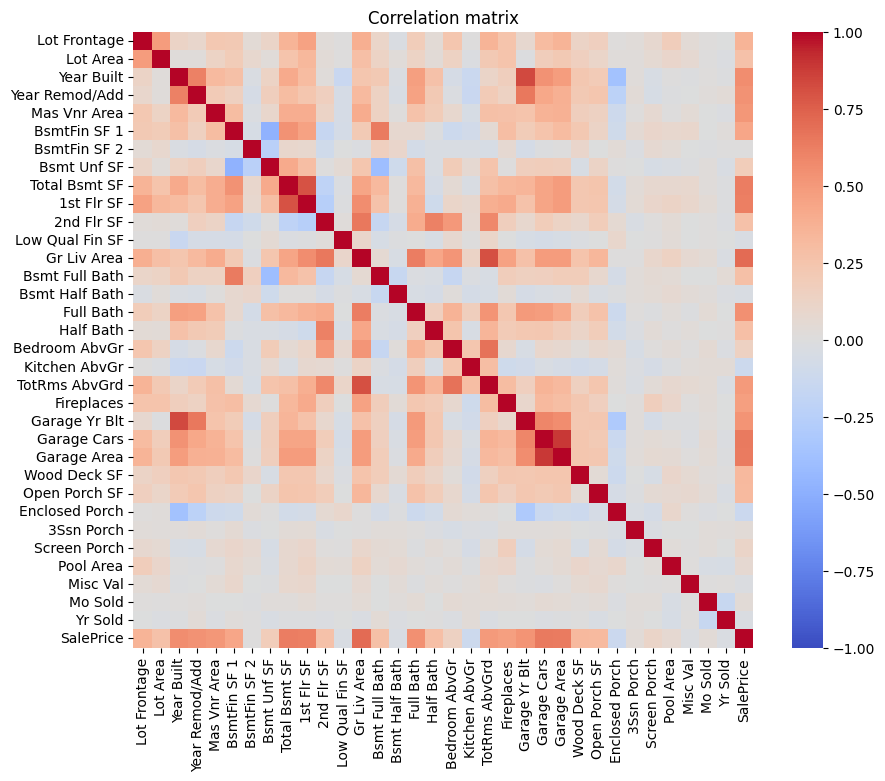

In [106]:
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_cols.corr(method='pearson'), cmap="coolwarm", center=0,vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()

# cria um mapa de calor para visualizar as correlações entre as variáveis numéricas,
# usando a paleta de cores "coolwarm" para destacar as correlações positivas e negativas.
# O parâmetro center=0 centraliza a escala de cores em torno de zero, facilitando a identificação de correlações fortes e fracas.

### Correlações Numéricas x Target

In [107]:
corr_pearson= numerical_cols.corr(method='pearson')['SalePrice']
#calcula as correlações entre as variáveis numéricas do DataFrame.
corr_pearson.sort_values(ascending=False)

SalePrice          1.00
Gr Liv Area        0.71
Garage Cars        0.65
Garage Area        0.64
Total Bsmt SF      0.63
1st Flr SF         0.62
Year Built         0.56
Full Bath          0.55
Year Remod/Add     0.53
Garage Yr Blt      0.53
Mas Vnr Area       0.51
TotRms AbvGrd      0.50
Fireplaces         0.47
BsmtFin SF 1       0.43
Lot Frontage       0.36
Wood Deck SF       0.33
Open Porch SF      0.31
Half Bath          0.29
Bsmt Full Bath     0.28
2nd Flr SF         0.27
Lot Area           0.27
Bsmt Unf SF        0.18
Bedroom AbvGr      0.14
Screen Porch       0.11
Pool Area          0.07
Mo Sold            0.04
3Ssn Porch         0.03
BsmtFin SF 2       0.01
Misc Val          -0.02
Yr Sold           -0.03
Bsmt Half Bath    -0.04
Low Qual Fin SF   -0.04
Kitchen AbvGr     -0.12
Enclosed Porch    -0.13
Name: SalePrice, dtype: float64

In [108]:
maiores_correlacoes_pearson = corr_pearson[abs(corr_pearson) > 0.5].sort_values(ascending=False)
maiores_correlacoes_pearson

SalePrice        1.00
Gr Liv Area      0.71
Garage Cars      0.65
Garage Area      0.64
Total Bsmt SF    0.63
1st Flr SF       0.62
Year Built       0.56
Full Bath        0.55
Year Remod/Add   0.53
Garage Yr Blt    0.53
Mas Vnr Area     0.51
Name: SalePrice, dtype: float64

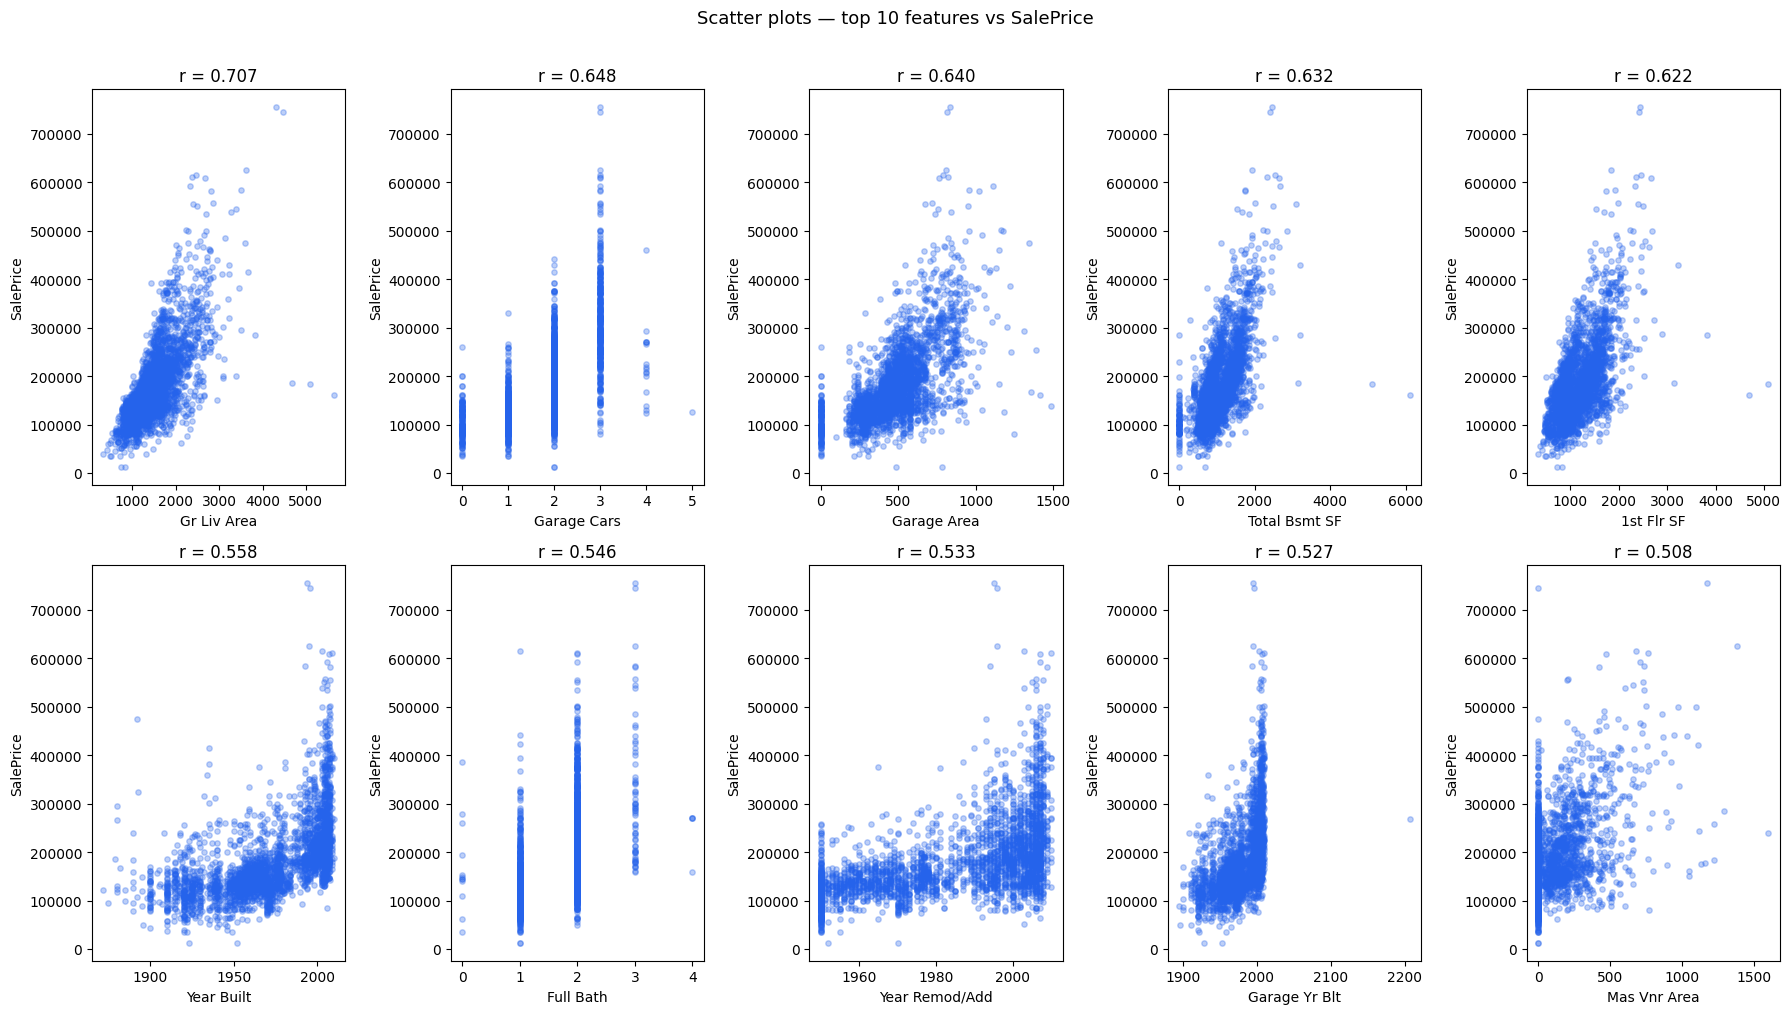

In [109]:
# scatter plots das top 15 features vs SalePrice

fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(maiores_correlacoes_pearson.drop('SalePrice').index):
    r = corr_pearson[col]
    axes[i].scatter(numerical_cols[col], numerical_cols['SalePrice'],
                    alpha=0.3, s=15, color='#2563eb')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'r = {r:.3f}')

plt.suptitle('Scatter plots — top 10 features vs SalePrice', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Correlações de Spearman para variáveis numéricas

In [110]:
maiores_correlacoes_sperman = df.corr(method='spearman', numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).head(11)
maiores_correlacoes_sperman

SalePrice        1.00
Overall Qual     0.81
Gr Liv Area      0.72
Garage Cars      0.70
Year Built       0.68
Garage Area      0.66
Garage Yr Blt    0.64
Full Bath        0.63
Total Bsmt SF    0.61
Year Remod/Add   0.60
1st Flr SF       0.58
Name: SalePrice, dtype: float64

In [111]:
# comparando pearson vs spearman
comparacao = pd.DataFrame({
    'Pearson': maiores_correlacoes_pearson,
    'Spearman': maiores_correlacoes_sperman
}).dropna()

comparacao['Diferença'] = (comparacao['Spearman'].abs() - comparacao['Pearson'].abs()).round(4)
comparacao = comparacao.sort_values('Spearman', key=abs, ascending=False)

print(comparacao.head(15))

                Pearson  Spearman  Diferença
SalePrice          1.00      1.00       0.00
Gr Liv Area        0.71      0.72       0.02
Garage Cars        0.65      0.70       0.05
Year Built         0.56      0.68       0.12
Garage Area        0.64      0.66       0.02
Garage Yr Blt      0.53      0.64       0.11
Full Bath          0.55      0.63       0.09
Total Bsmt SF      0.63      0.61      -0.03
Year Remod/Add     0.53      0.60       0.07
1st Flr SF         0.62      0.58      -0.04


### Multicolinearidade de Variáveis numéricas

In [115]:
# seleciona as variáveis numéricas (sem SalePrice)
vif_cols = numerical_cols.drop(columns=['SalePrice']).dropna()

# calcula VIF para cada variável
vif_data = pd.DataFrame({
    'variavel': vif_cols.columns,
    'VIF': [variance_inflation_factor(vif_cols.values, i) for i in range(vif_cols.shape[1])]
})

# ordena do maior para o menor
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# classifica o nível de multicolinearidade
def classifica_vif(vif):
    if vif >= 10:
        return 'grave'
    elif vif >= 5:
        return 'moderada'
    else:
        return 'baixa'

vif_data['multicolinearidade'] = vif_data['VIF'].apply(classifica_vif)

print(vif_data.to_string(index=False))

       variavel      VIF multicolinearidade
  Total Bsmt SF      inf              grave
    Gr Liv Area      inf              grave
    Bsmt Unf SF      inf              grave
   BsmtFin SF 2      inf              grave
   BsmtFin SF 1      inf              grave
     2nd Flr SF      inf              grave
Low Qual Fin SF      inf              grave
     1st Flr SF      inf              grave
  Garage Yr Blt 27002.89              grave
        Yr Sold 22093.80              grave
     Year Built 20200.33              grave
 Year Remod/Add 18575.11              grave
  TotRms AbvGrd    78.44              grave
  Kitchen AbvGr    41.00              grave
    Garage Cars    39.39              grave
    Garage Area    34.75              grave
  Bedroom AbvGr    30.08              grave
      Full Bath    26.57              grave
   Lot Frontage    16.65              grave
        Mo Sold     6.36           moderada
       Lot Area     4.67              baixa
 Bsmt Full Bath     3.60        

c:\Users\erica\Documents\Mestrado\Projetos\Advanced_DS\Ames_Housing_Project\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### Análise de Multicolinearidade (VIF - Variance Inflation Factor)



| Variável | VIF | Problema | Ação |
| :--- | :--- | :--- | :--- |
| **Total Bsmt SF** | inf | Soma exata de BsmtFin SF 1 + BsmtFin SF 2 + Bsmt Unf SF | Manter — remover os componentes |
| **BsmtFin SF 1** | inf | Componente de Total Bsmt SF | Remover |
| **BsmtFin SF 2** | inf | Componente de Total Bsmt SF | Remover |
| **Bsmt Unf SF** | inf | Componente de Total Bsmt SF | Remover |
| **Gr Liv Area** | inf | Soma exata de 1st Flr SF + 2nd Flr SF + Low Qual Fin SF | Manter — remover os componentes |
| **1st Flr SF** | inf | Componente de Gr Liv Area | Remover |
| **2nd Flr SF** | inf | Componente de Gr Liv Area | Remover |
| **Low Qual Fin SF** | inf | Componente de Gr Liv Area | Remover |
| **Garage Yr Blt** | 27002.89 | Alta correlação com Year Built e Year Remod/Add | Transformar em garage_age = Yr Sold - Garage Yr Blt |
| **Yr Sold** | 22093.80 | Alta correlação com variáveis de tempo | Manter como referência — reavaliar pós-transformações |
| **Year Built** | 20200.33 | Alta correlação com Year Remod/Add e Garage Yr Blt | Transformar em house_age = Yr Sold - Year Built |
| **Year Remod/Add** | 18575.11 | Alta correlação com Year Built | Transformar em years_since_remod = Yr Sold - Year Remod/Add |
| **TotRms AbvGrd** | 78.44 | Correlacionada com Bedroom AbvGr e Full Bath | Recalcular VIF após correções acima |
| **Kitchen AbvGr** | 41.00 | Quase constante — 99% = 1 | Recalcular VIF após correções — avaliar exclusão |
| **Garage Cars** | 39.39 | Correlacionada com Garage Area | Recalcular VIF após correções — manter uma das duas |
| **Garage Area** | 34.75 | Correlacionada com Garage Cars | Recalcular VIF após correções — manter uma das duas |
| **Bedroom AbvGr** | 30.08 | Correlacionada com TotRms AbvGrd | Recalcular VIF após correções |
| **Full Bath** | 26.57 | Correlacionada com TotRms AbvGrd | Recalcular VIF após correções |
| **Lot Frontage** | 16.65 | Alta | Recalcular VIF após correções |
| **Mo Sold** | 6.36 | Moderada | Recalcular VIF após correções |
| **Lot Area** | 4.67 | Baixa | Manter |
| **Bsmt Full Bath** | 3.60 | Baixa | Manter |
| **Half Bath** | 3.42 | Baixa | Manter |
| **Fireplaces** | 2.79 | Baixa | Manter |
| **Mas Vnr Area** | 1.95 | Baixa | Manter |
| **Open Porch SF** | 1.92 | Baixa | Manter |
| **Wood Deck SF** | 1.92 | Baixa | Manter |
| **Enclosed Porch** | 1.40 | Baixa | Manter |
| **Bsmt Half Bath** | 1.22 | Baixa | Manter |
| **Screen Porch** | 1.18 | Baixa | Manter |
| **Pool Area** | 1.11 | Baixa | Será substituída por has_pool |
| **Misc Val** | 1.08 | Baixa | Manter |
| **3Ssn Porch** | 1.03 | Baixa | Manter |

## Correlações variáveis categóricas X Target

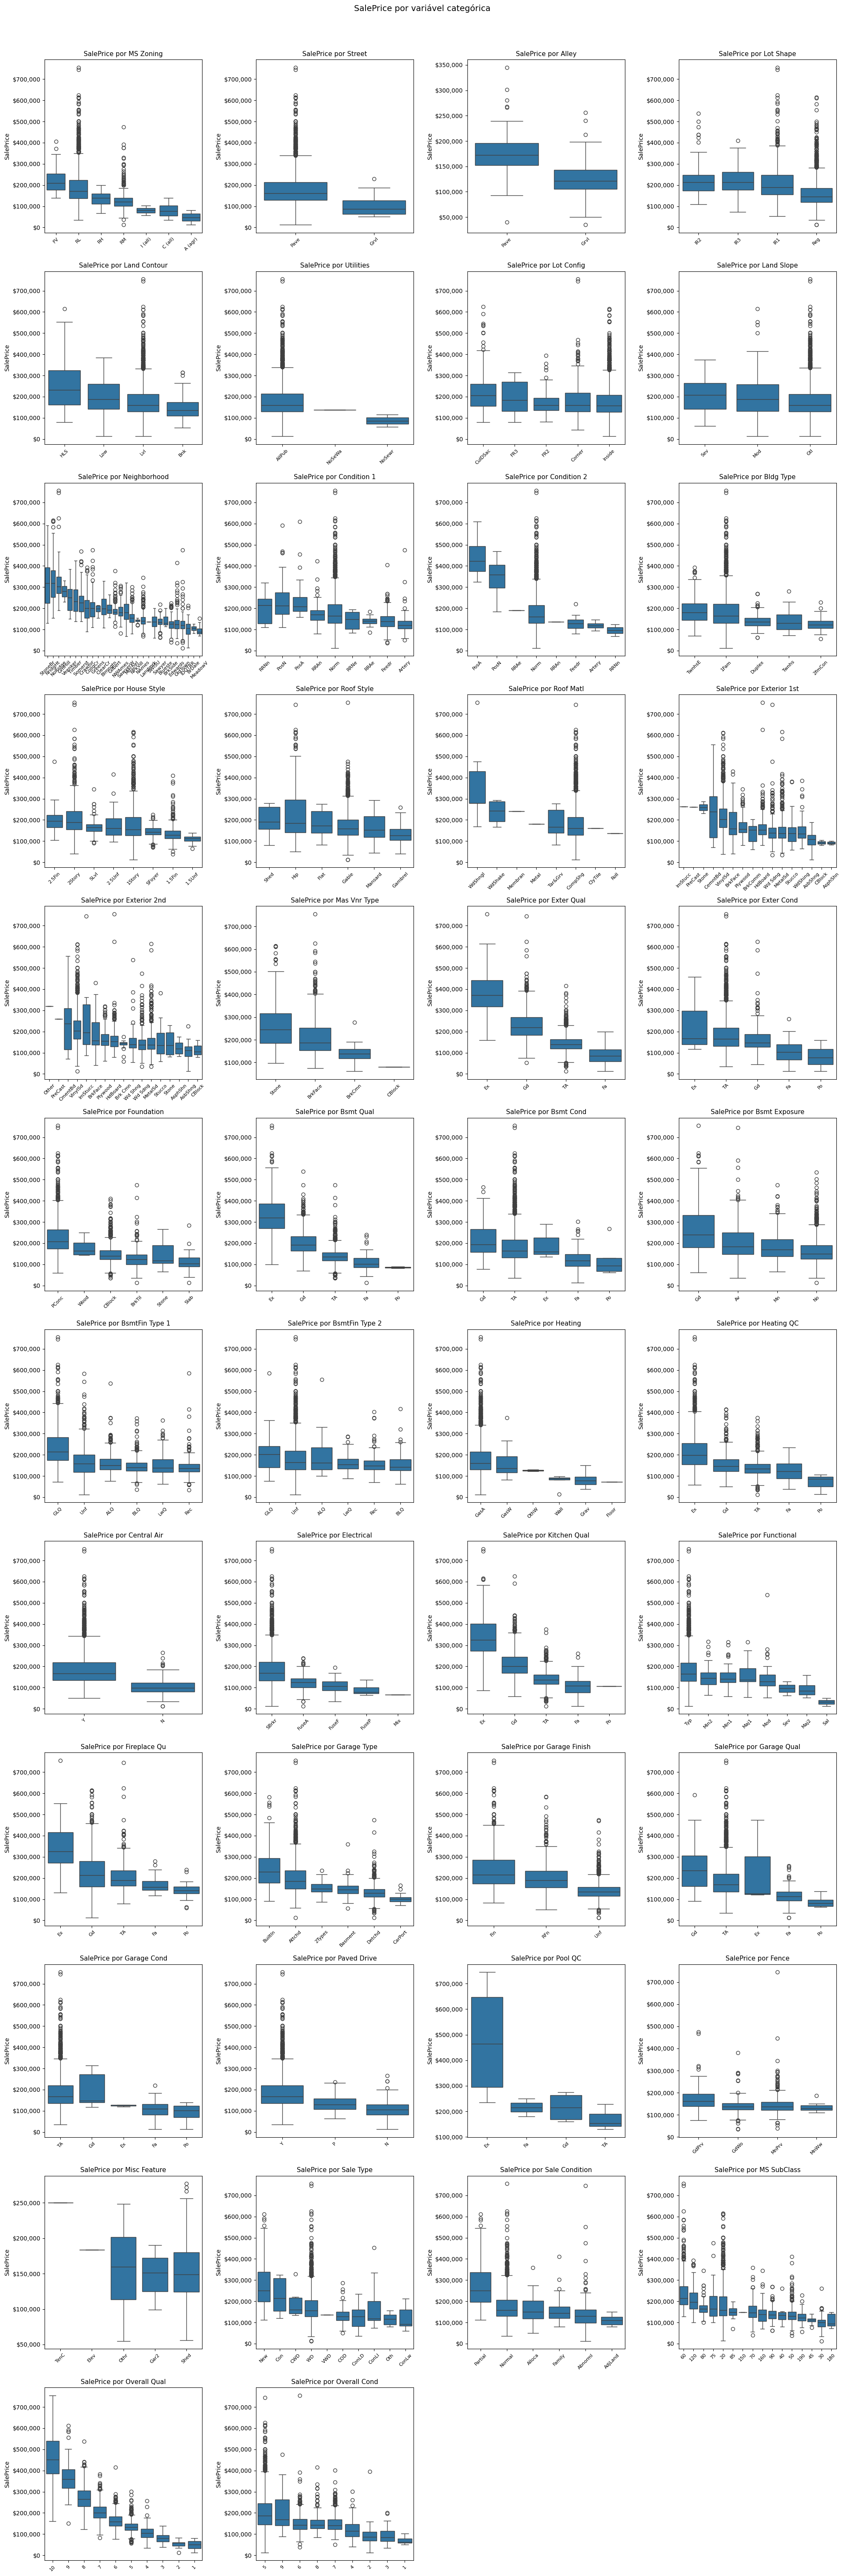

In [112]:

fig, axes = plt.subplots(12,4, figsize=(20, 60))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ordem = (
        df.groupby(col)['SalePrice']
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )
    sns.boxplot(
        data=df, x=col, y='SalePrice',
        order=ordem, ax=axes[i]
    )
    axes[i].set_title(f'SalePrice por {col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('SalePrice por variável categórica', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Multicolinearidade de Variáveis Categoricas

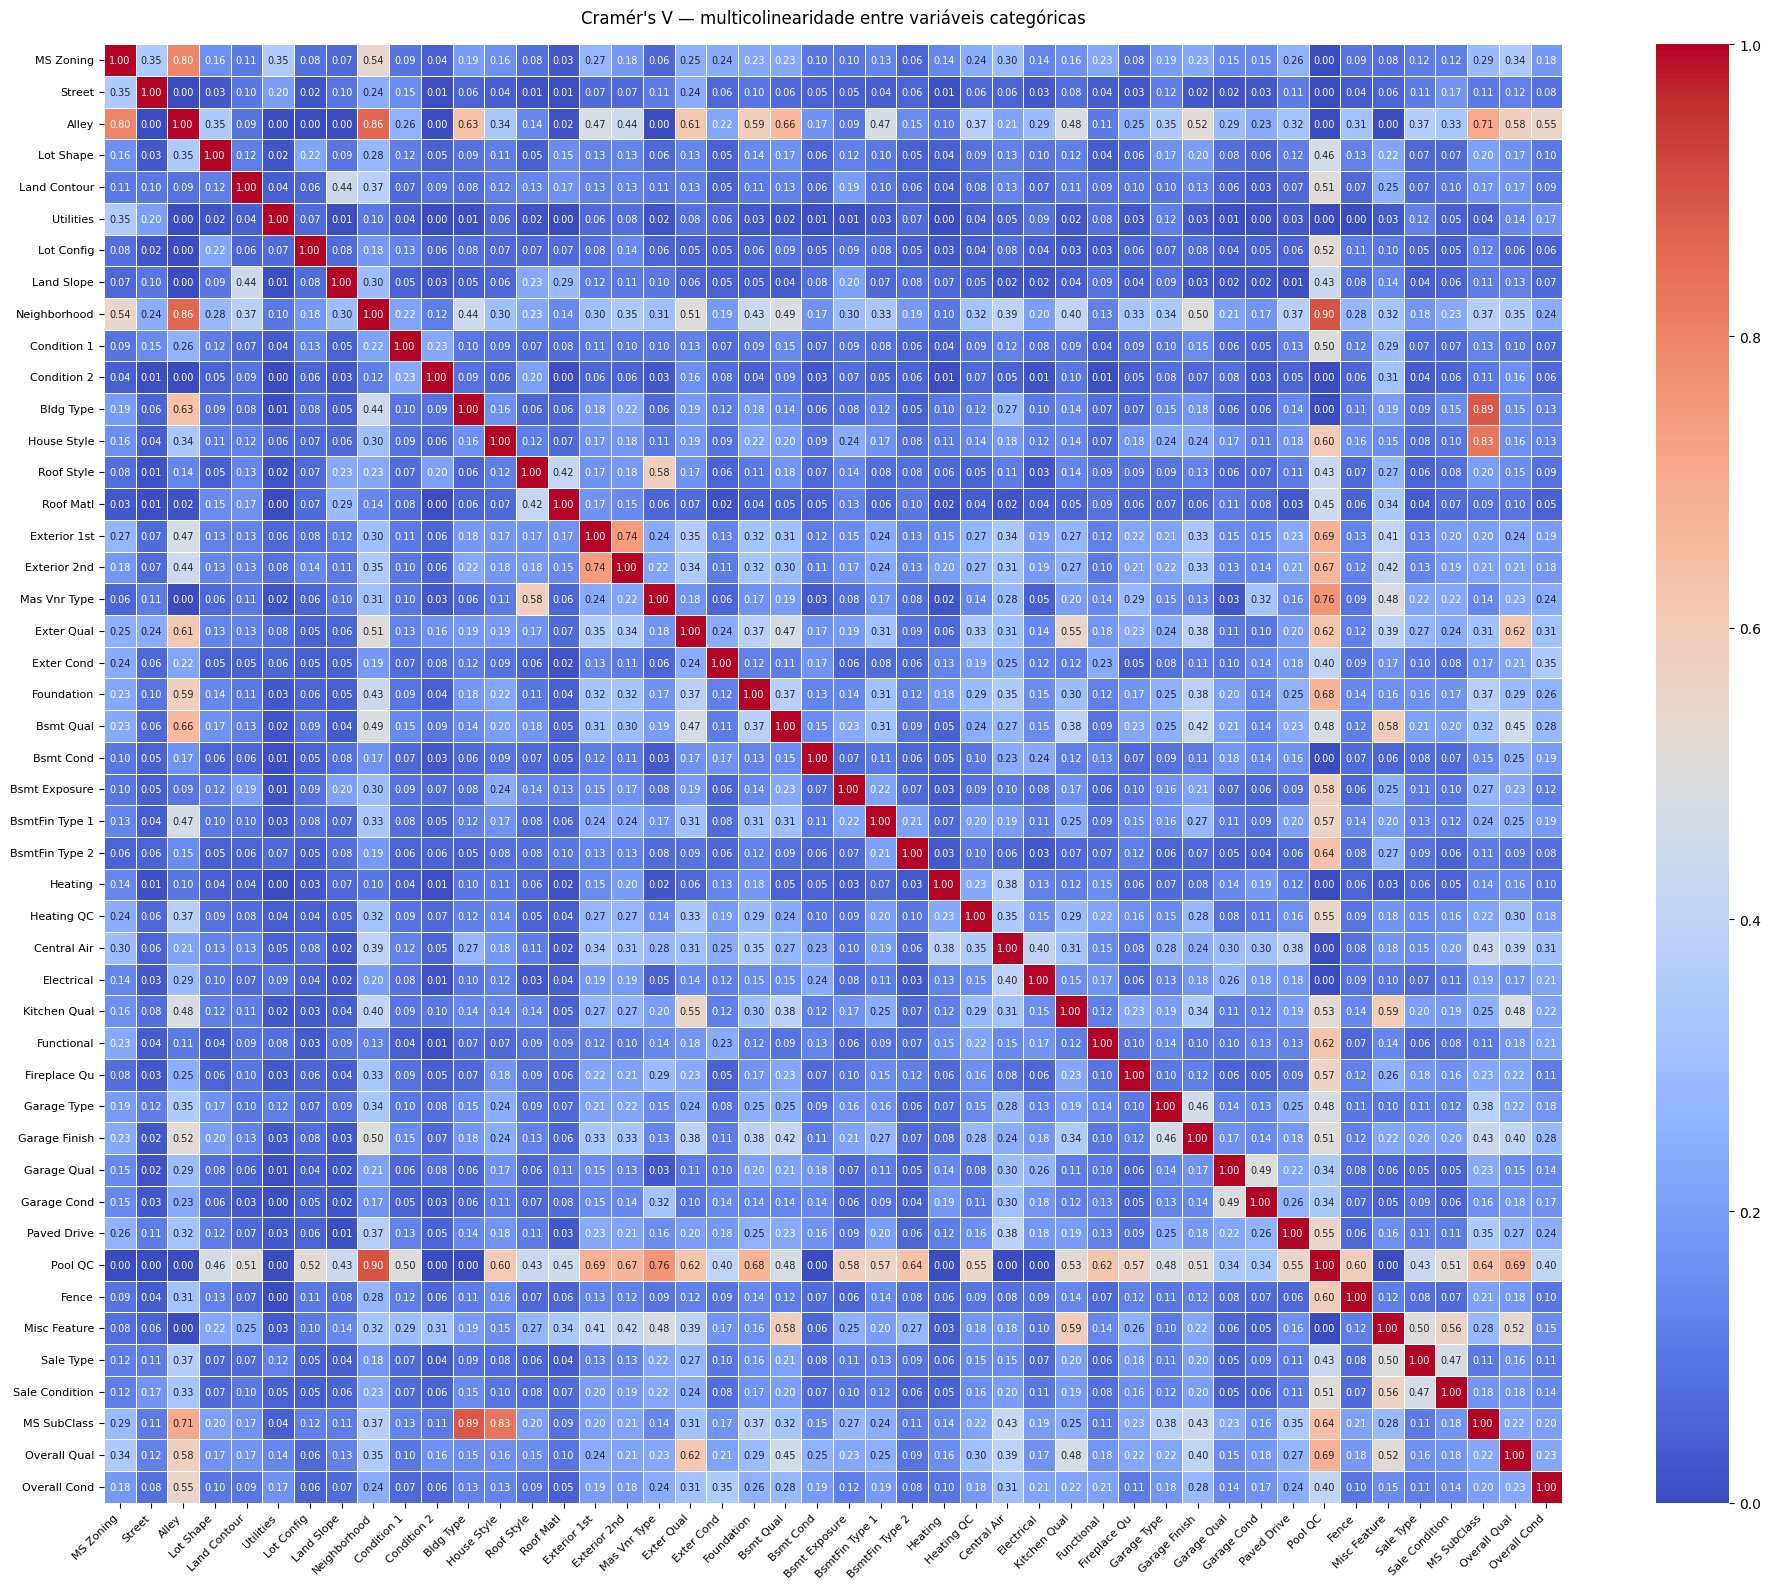


Pares com Cramér's V > 0.5 (possível multicolinearidade):

    variavel_1     variavel_2  cramers_v
  Neighborhood        Pool QC       0.90
     Bldg Type    MS SubClass       0.89
         Alley   Neighborhood       0.86
   House Style    MS SubClass       0.83
     MS Zoning          Alley       0.80
  Mas Vnr Type        Pool QC       0.76
  Exterior 1st   Exterior 2nd       0.74
         Alley    MS SubClass       0.71
  Exterior 1st        Pool QC       0.69
       Pool QC   Overall Qual       0.69
    Foundation        Pool QC       0.68
  Exterior 2nd        Pool QC       0.67
         Alley      Bsmt Qual       0.66
       Pool QC    MS SubClass       0.64
BsmtFin Type 2        Pool QC       0.64
         Alley      Bldg Type       0.63
    Functional        Pool QC       0.62
    Exter Qual        Pool QC       0.62
    Exter Qual   Overall Qual       0.62
         Alley     Exter Qual       0.61
   House Style        Pool QC       0.60
       Pool QC          Fence       0.

In [114]:
cat_cols_vif = categorical_cols.tolist()

def cramers_v(x, y):
    tabela = pd.crosstab(x, y)
    r, k = tabela.shape
    # evita divisão por zero quando uma variável tem só 1 categoria
    if min(r, k) <= 1:
        return 0.0
    chi2, _, _, _ = chi2_contingency(tabela)
    n = len(x)
    v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return round(v, 4)

matriz = pd.DataFrame(index=cat_cols_vif, columns=cat_cols_vif, dtype=float)

for col1 in cat_cols_vif:
    for col2 in cat_cols_vif:
        if col1 == col2:
            matriz.loc[col1, col2] = 1.0
        else:
            dados = df[[col1, col2]].dropna()
            matriz.loc[col1, col2] = cramers_v(dados[col1], dados[col2])

# heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(
    matriz.astype(float),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0.5,
    vmin=0, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title("Cramér's V — multicolinearidade entre variáveis categóricas", pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# pares com associação alta (V > 0.5)
print("\nPares com Cramér's V > 0.5 (possível multicolinearidade):\n")
pares = []
for i, col1 in enumerate(cat_cols_vif):
    for j, col2 in enumerate(cat_cols_vif):
        if j <= i:
            continue
        v = matriz.loc[col1, col2]
        if v > 0.5:
            pares.append({'variavel_1': col1, 'variavel_2': col2, 'cramers_v': v})

pares_df = pd.DataFrame(pares).sort_values('cramers_v', ascending=False)
print(pares_df.to_string(index=False))

### Análise de Multicolinearidade Categórica (Cramér's V > 0.5)



| Variável 1 | Variável 2 | Cramér's V | Análise Técnica e Decisão |
| :--- | :--- | :---: | :--- |
| **Neighborhood** | **Pool QC** | 0.90 | **Altíssima colinearidade.** Piscinas só aparecem em bairros específicos. |
| **Bldg Type** | **MS SubClass** | 0.89 | **Redundante.** MS SubClass já abrange o tipo de habitação. |
| **Alley** | **Neighborhood** | 0.86 | **Forte associação geográfica.** Becos são restritos a certas vizinhanças. |
| **House Style** | **MS SubClass** | 0.83 | **Redundante.** MS SubClass engloba o estilo da casa. |
| **MS Zoning** | **Alley** | 0.80 | Forte relação entre zoneamento e infraestrutura de acesso. |
| **Mas Vnr Type** | **Pool QC** | 0.76 | Casas com revestimentos caros tendem a ser as que possuem piscina. |
| **Exterior 1st** | **Exterior 2nd** | 0.74 | **Confirmar exclusão** de Exterior 2nd por redundância. |
| **Alley** | **MS SubClass** | 0.71 | Correlação moderada-forte. |
| **Exterior 1st** | **Pool QC** | 0.69 | Associação entre acabamento externo e presença de lazer luxuoso. |
| **Pool QC** | **Overall Qual** | 0.69 | Piscinas estão concentradas em casas de alta qualidade geral. |
| **Foundation** | **Pool QC** | 0.68 | Provável relação com técnicas de construção modernas (PConc). |
| **Exterior 2nd** | **Pool QC** | 0.67 | Redundância cruzada com Exterior 1st. |
| **Alley** | **Bsmt Qual** | 0.66 | Correlação geográfica afetando características internas. |
| **Pool QC** | **MS SubClass** | 0.64 | Tipos específicos de habitação (luxo) possuem piscina. |
| **BsmtFin Type 2** | **Pool QC** | 0.64 | Associação estatística (provável baixa variância em ambas). |
| **Alley** | **Bldg Type** | 0.63 | Redundância com localização geográfica. |
| **Functional** | **Pool QC** | 0.62 | — |
| **Exter Qual** | **Pool QC** | 0.62 | Qualidade externa excelente caminha junto com piscina. |
| **Exter Qual** | **Overall Qual** | 0.62 | **Redundante.** Qualidade específica reflete a geral. |
| **Alley** | **Exter Qual** | 0.61 | — |
| **House Style** | **Pool QC** | 0.60 | — |
| **Pool QC** | **Fence** | 0.60 | Casas com piscina frequentemente possuem cercas por segurança/privacidade. |
| **Kitchen Qual** | **Misc Feature** | 0.59 | Variáveis com muitos 'None' podem inflar o V de Cramér. |
| **Alley** | **Foundation** | 0.59 | — |
| **Bsmt Qual** | **Misc Feature** | 0.58 | — |
| **Roof Style** | **Mas Vnr Type** | 0.58 | Estilo arquitetônico consistente. |
| **Alley** | **Overall Qual** | 0.58 | — |
| **Bsmt Exposure** | **Pool QC** | 0.58 | — |
| **Fireplace Qu** | **Pool QC** | 0.57 | — |
| **BsmtFin Type 1** | **Pool QC** | 0.57 | — |
| **Misc Feature** | **Sale Condition** | 0.56 | — |
| **Heating QC** | **Pool QC** | 0.55 | — |
| **Alley** | **Overall Cond** | 0.55 | — |
| **Paved Drive** | **Pool QC** | 0.55 | — |
| **Exter Qual** | **Kitchen Qual** | 0.55 | Qualidade de acabamento é consistente na casa toda. |
| **MS Zoning** | **Neighborhood** | 0.54 | Zoneamento é intrínseco ao bairro. |
| **Kitchen Qual** | **Pool QC** | 0.53 | — |
| **Misc Feature** | **Overall Qual** | 0.52 | — |
| **Alley** | **Garage Finish** | 0.52 | — |
| **Lot Config** | **Pool QC** | 0.52 | — |
| **Garage Finish** | **Pool QC** | 0.51 | — |
| **Land Contour** | **Pool QC** | 0.51 | — |
| **Pool QC** | **Sale Condition** | 0.51 | — |
| **Neighborhood** | **Exter Qual** | 0.51 | Bairros nobres têm melhores acabamentos. |
| **Misc Feature** | **Sale Type** | 0.50 | — |

Pool QC aparece em quase todos os pares — desconsiderar
Pool QC vai ser convertida para binária has_pool — e como só 13 casas têm piscina, ela está criando associações espúrias com praticamente tudo. Todos os pares envolvendo Pool QC podem ser ignorados.
